# SPLIT-ST workflow

This notebook runs the standalone Python SPLIT workflow on a deterministic AnnData fixture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import splitst as split

In [2]:
adata, weights, reference = split.create_split_fixture()
adata

AnnData object with n_obs × n_vars = 240 × 120
    obs: 'primary_cell_type', 'secondary_cell_type', 'simulated_contamination'
    obsm: 'spatial'
    layers: 'counts', 'clean_counts'

## Default SPLIT purification

In [3]:
split.purify(
    adata,
    deconvolution_weights=weights,
    reference=reference,
    primary_cell_type=adata.obs["primary_cell_type"],
)
adata.obs[["first_type", "second_type", "weight_first_type", "weight_second_type", "purification_status"]].head()

,first_type,second_type,weight_first_type,weight_second_type,purification_status
Cell_0001,CellType_1,<NA>,1.0,0.0,raw
Cell_0002,CellType_4,<NA>,1.0,0.0,raw
Cell_0003,CellType_2,<NA>,1.0,0.0,raw
Cell_0004,CellType_2,<NA>,1.0,0.0,raw
Cell_0005,CellType_3,<NA>,1.0,0.0,raw


## Spatially aware selective purification

In [4]:
split.spatial_score(
    adata,
    deconvolution_weights=weights,
    primary_cell_type=adata.obs["primary_cell_type"],
    secondary_cell_type=adata.obs["secondary_cell_type"],
)
split.balance(adata, threshold=0.15)
pd.crosstab(adata.obs["simulated_contamination"], adata.obs["split_balance_status"])

split_balance_status,purified,raw
simulated_contamination,,
False,0,155
True,85,0


## SPLIT-shift label swaps

In [5]:
neighbor_idx = adata.uns["split_spatial_neighbors"]["indices"]
neighbor_labels = []
for i, neighbors in enumerate(neighbor_idx):
    valid = [j for j in neighbors if j >= 0 and j != i]
    neighbor_labels.append(adata.obs["primary_cell_type"].iloc[valid].mode().iloc[0] if valid else adata.obs["primary_cell_type"].iloc[i])
adata.obs["first_type_neighborhood"] = neighbor_labels
split.balance(adata, threshold=0.15, result_layer="split_balanced_shift", swap_labels=True)
adata.obs["split_shift_swap"].value_counts()

split_shift_swap
False    240
Name: count, dtype: int64

## Residual transcript reassignment

In [6]:
split.reassign_residuals(adata, mode="count_proportional")
pd.Series({
    "raw_total": float(np.asarray(adata.layers["counts"]).sum()),
    "balanced_total": float(adata.layers["split_balanced"].sum()),
    "reassigned_total": float(adata.layers["split_reassigned"].sum()),
    "operator_nonzero": adata.uns["split_reassignment_operator"].nnz,
})

raw_total           498163.014452
balanced_total      462862.977522
reassigned_total    498163.014452
operator_nonzero      1700.000000
dtype: float64

## Benchmark table

In [7]:
def as_array(layer):
    x = adata.layers[layer]
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

clean = as_array("clean_counts")
pd.DataFrame([
    {
        "layer": layer,
        "l2_to_clean": float(np.linalg.norm(as_array(layer) - clean)),
        "total_counts": float(as_array(layer).sum()),
        "min_value": float(as_array(layer).min()),
    }
    for layer in ["counts", "split_purified", "split_balanced", "split_reassigned"]
])

,layer,l2_to_clean,total_counts,min_value
0,counts,3.934052e+02,498163.014452,2.0
1,split_purified,3.051344e-09,462862.977522,1.6
2,split_balanced,3.051344e-09,462862.977522,1.6
3,split_reassigned,3.888848e+02,498163.014452,2.0


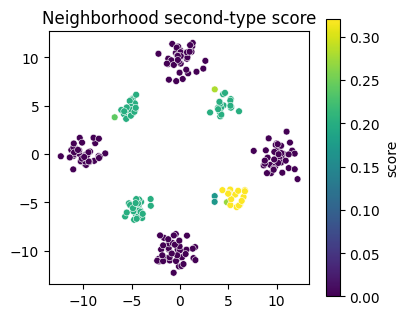

In [8]:
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sc = ax.scatter(
    adata.obsm["spatial"][:, 0],
    adata.obsm["spatial"][:, 1],
    c=adata.obs["neighborhood_weights_second_type"],
    cmap="viridis",
    s=24,
    edgecolor="white",
    linewidth=0.4,
)
ax.set_title("Neighborhood second-type score")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="score")
plt.show()